In [4]:
# Load model directly
import argparse
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
from copy import deepcopy
import re
from nltk.translate.bleu_score import sentence_bleu
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoTokenizer, BertForMaskedLM, BertConfig

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn.functional import cross_entropy
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torch.utils.data import DataLoader, Subset, RandomSampler
torch.set_default_dtype(torch.float32)
import tensorflow_hub as hub

from utils import *

In [5]:
# For MNLI matched Val Set
dataName='mnli_matched_val'
dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_matched.txt'
tgtModel='textattack/bert-base-uncased-MNLI'
tgt_model_name="BERT_MNLI"
# tgtModel="textattack/roberta-base-MNLI"
# ---------------------------------------- #

# # Read MNLI mismatched Val Set
# dataName='mnli_matched_val'
# dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_matched.txt'
# tgtModel='textattack/bert-base-uncased-MNLI'
# tgt_model_name="BERT_MNLI"
# tgtModel="textattack/roberta-base-MNLI"
# ---------------------------------------- #

# # Read SNLI Val Set
# dataName='snli_val'
# dataPath='/usa/taikun/07_transencoder/3datasets/snli/snli/snli.txt'
# tgtModel="textattack/bert-base-uncased-snli"
# tgtModel="pepa/roberta-base-snli"

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
vocabSize = tokenizer.vocab_size
print(f"Vocabulary Size: {vocabSize}")

texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False,\
    lower=False, dataName=dataName, dataPath=dataPath, tgtModel_name=tgt_model_name)

print(texts_[:3])
print(labels_[:3])

Vocabulary Size: 28996
BERT_UNCASED
[('In Temple Bar , the bookshop at the Gallery of Photography carries a large selection of photographic publications , and the Flying Pig is a secondhand bookshop .', 'There is a bookshop at the gallery .'), ('On Naxos , you can walk through the pretty villages of the Tragea Valley and the foothills of Mount Zas , admiring Byzantine churches and exploring olive groves at your leisure .', 'Naxos is a place with beautiful scenery for leisure .'), ('Impossible .', 'Impossible , unless circumstances are met .')]
[1, 1, 2]


# Evaluaiton on non-SBERT

In [6]:
total = 0
sprobs, slabels = [], []

for sample_inx in range(len(texts_)): # batch size is 1
    if total % 10 == 0:
        print(total," th document.")
    total += 1
    text = texts_[sample_inx]
    label = labels_[sample_inx]
    # print("text", text)
    # print("label", label)
# replace machanism
    sLabels, sProbs = query([text], tgtModel=tgtModel)  # st [bs=1, trueDocLen]
    
    slabels.append(sLabels.item())
    sprobs.append(sProbs)
    
    # if total == 2:
    #     print(total," th document.")
    #     break
    

0  th document.
10  th document.
20  th document.
30  th document.
40  th document.
50  th document.
60  th document.
70  th document.
80  th document.
90  th document.
100  th document.
110  th document.
120  th document.
130  th document.
140  th document.
150  th document.
160  th document.
170  th document.
180  th document.
190  th document.
200  th document.
210  th document.
220  th document.
230  th document.
240  th document.
250  th document.
260  th document.
270  th document.
280  th document.
290  th document.
300  th document.
310  th document.
320  th document.
330  th document.
340  th document.
350  th document.
360  th document.
370  th document.
380  th document.
390  th document.
400  th document.
410  th document.
420  th document.
430  th document.
440  th document.
450  th document.
460  th document.
470  th document.
480  th document.
490  th document.
500  th document.
510  th document.
520  th document.
530  th document.
540  th document.
550  th document.
560

In [7]:
# # evaluation on sentence-bert
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# import torch

# nums_samples_inference = 2
# texts_ = texts_[:nums_samples_inference]
# labels_ = labels_[:nums_samples_inference]

# model = AutoModelForSequenceClassification.from_pretrained('cross-encoder/nli-roberta-base')
# tokenizer = AutoTokenizer.from_pretrained('cross-encoder/nli-roberta-base')

# # features = tokenizer(['A man is eating pizza', 'A black race car starts up in front of a crowd of people.'], ['A man eats something', 'A man is driving down a lonely road.'],  padding=True, truncation=True, return_tensors="pt")
# processed_texts = [[sample[0], sample[1]] for sample in texts_]
# features = tokenizer(processed_texts,  padding=True, truncation=True, return_tensors="pt")

# # if tgtModel == 'ROBERTA_SNLI':
# #     print("ROBERTA_SNLI")
# #     mapping = {'contradiction': 2, 'entailment': 0, 'neutral': 1}

# # elif tgtModel == 'ROBERTA_MNLI':
# #     print("ROBERTA_MNLI")
# #     mapping = {'contradiction': 0, 'entailment': 2, 'neutral': 1}
    
# # else:
# #     print("BERT_UNCASED")
# #     mapping = {'contradiction': 0, 'entailment': 1, 'neutral': 2}

# model.eval()
# with torch.no_grad():
#     scores = model(**features).logits
#     print(scores)

#     label_mapping = ['contradiction', 'entailment', 'neutral']
#     labels = [label_mapping[score_max] for score_max in scores.argmax(dim=1)]
#     print(labels)
#     slabels = [mapping[l] for l in labels]
#     print(slabels)

In [8]:
# # For MNLI mismatched Val Set
# startFromSample = 0

# dataName='mnli_mismatched_val'
# dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_mismatched.txt'
# importantTokensFile='/usa/taikun/07_transencoder/0dataProcessing/mnli/tokens_mnli_mismatched_val_0.json_hypothesis.json'
# tgtModel="textattack/bert-base-uncased-MNLI"
# tgt_model_name="BERT_MNLI"

# attackerName='BERTFineTuned'
# # attackerPath='/usa/taikun/07_transencoder/MNLI/attackerModels/' 
# numsAttackedTokens=0.7
# maxLenDoc=512

# alpha=0.7

# attackerFile='/usa/taikun/07_transencoder/1training/mnli/hypothesis/9Sep/attacker_mnlimatched_0.5_1_500_3.1694.pth'
# numCandidatesEachToken=80 # total numbers of desire attacked tokens
# numsMaxCandidates=8
# ifPrintAttackProcess=True

# mode = 'nli'
# #on='premise'
# on='hypothesis'

# evaluationPartition= 'temp.json'

# tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
# vocabSize = tokenizer.vocab_size
# print(f"Vocabulary Size: {vocabSize}")

# # texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False,\
# #     lower=False, dataName=dataName, dataPath=dataPath, tgtModel_name=tgt_model_name)

# # print(texts_[:3])
# # print(labels_[:3])

In [9]:
# text = [('Luis Alonso, Luis Alonso, says to him, Luis Alonso\'s friend.', 'They said they do not know the man.'),
#         ('Luis Alonso, Luis Alonso, says to him, Luis Alonso\'s friend.', 'hey said they do graphical know the man.')]

# sLabels, sProbs = query(text, tgtModel=tgtModel)  # st [bs=1, trueDocLen]
# print(sLabels)
# print(sProbs)

In [10]:

# # For MNLI matched Val Set
# dataName='mnli_matched_val'
# dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_matched.txt'
# # tgtModel='textattack/bert-base-uncased-MNLI'
# # tgtModel='Alireza1044/albert-base-v2-mnli'
# tgtModel="textattack/roberta-base-MNLI"

# attackerName='BERTMaskedLM'
# attackerPath='None' 
# numsAttackedTokens=1.0
# maxLenDoc=512

# alpha=-0.99

# mode = 'nli'
# attackerFile='None'
# numCandidatesEachToken=150 # total numbers of desire attacked tokens
# numsMaxCandidates=10
# ifPrintAttackProcess=True
# evaluationPartition="None"

# startFromSample=0
# numsProcessedSamples= 1000


# # ### 1.2 Tokenize Dataset
# # examples is list[str]
# # max_length is int
# tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
# vocabSize = tokenizer.vocab_size
# print(f"Vocabulary Size: {vocabSize}")

# texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False, lower=False, dataName=dataName, dataPath=dataPath)
# # labels_ = [label.strip() for label in labels_]
# # labels_ = labelProcessing(data=dataName, labels = labels_)

# texts_ = texts_[:numsProcessedSamples]
# labels_ = labels_[:numsProcessedSamples]

# # texts_ = texts_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]
# # labels_ = labels_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]

# print(f"Evaluation Data Size: {len(texts_)}")


In [11]:

# # For SNLI Val Set
# dataName='snli_val'
# dataPath='/usa/taikun/07_transencoder/3datasets/snli/snli/snli.txt'
# # tgtModel="textattack/bert-base-uncased-snli"
# tgtModel="pepa/roberta-base-snli"
# # if not to use ROBERTA SNLI remeber change back the label mapping
# attackerName='BERTMaskedLM'
# attackerPath='None' 
# numsAttackedTokens=1.0
# maxLenDoc=512

# alpha=-0.99

# mode = 'nli'
# attackerFile='None'
# numCandidatesEachToken=150 # total numbers of desire attacked tokens
# numsMaxCandidates=10
# ifPrintAttackProcess=True
# evaluationPartition="None"

# startFromSample=0
# numsProcessedSamples= 1000


# # ### 1.2 Tokenize Dataset
# # examples is list[str]
# # max_length is int
# tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", model_max_length=512)
# vocabSize = tokenizer.vocab_size
# print(f"Vocabulary Size: {vocabSize}")

# texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False, lower=False, dataName=dataName, dataPath=dataPath)
# # labels_ = [label.strip() for label in labels_]
# # labels_ = labelProcessing(data=dataName, labels = labels_)

# texts_ = texts_[:numsProcessedSamples]
# labels_ = labels_[:numsProcessedSamples]

# # texts_ = texts_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]
# # labels_ = labels_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]

# print(f"Evaluation Data Size: {len(texts_)}")



In [12]:
# print(len(slabels))
# print(slabels)

# labels_ = labels_[:len(slabels)]
# print(len(labels_))
# print(labels_)

# # print(sprobs)


accuracy 0.845


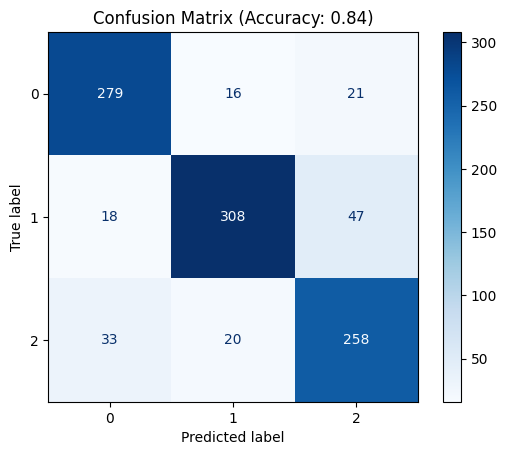

0.845

In [13]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Calculate accuracy
accuracy = accuracy_score(labels_, slabels)
print("accuracy", accuracy)

# Generate confusion matrix
conf_matrix = confusion_matrix(labels_, slabels)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2f})')
plt.show()

accuracy

In [14]:
from transformers import BertTokenizer

# Initialize the tokenizer (you can use 'bert-base-uncased' or any other pre-trained model)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Define very long premise and hypothesis
premise = "This is an example premise. "  # Repeat to make it long
hypothesis = "This is an example hypothesis. "  # Repeat to make it long

# Tokenize the premise and hypothesis separately with truncation
tokenized_premise = tokenizer(premise, max_length=256, truncation=True, add_special_tokens=False)
tokenized_hypothesis = tokenizer(hypothesis, max_length=256, truncation=True, add_special_tokens=False)

# Combine the tokenized premise and hypothesis with [CLS] and [SEP] tokens
input_ids = (
    [tokenizer.cls_token_id] + 
    tokenized_premise['input_ids'] + 
    [tokenizer.sep_token_id] + 
    tokenized_hypothesis['input_ids'] + 
    [tokenizer.sep_token_id]
)

# Pad if necessary to the max length (512 tokens)
input_ids = input_ids[:512]  # Truncate if the length exceeds 512

# Convert tokens to the actual tokens (not IDs)
tokens = tokenizer.convert_ids_to_tokens(input_ids)

print("Token IDs:", input_ids)
print("Tokens:", tokens)

# Find the indices of the [SEP] tokens
sep_indices = [i for i, token in enumerate(tokens) if token == '[SEP]']

# Extract the tokenized premise and hypothesis
tokenized_premise = tokens[1:sep_indices[0]]  # From [CLS] to first [SEP]
tokenized_hypothesis = tokens[sep_indices[0] + 1:sep_indices[1]]  # Between first [SEP] and second [SEP]

# Decode the tokens back to strings
decoded_premise = tokenizer.convert_tokens_to_string(tokenized_premise)
decoded_hypothesis = tokenizer.convert_tokens_to_string(tokenized_hypothesis)

print("Decoded Premise:", decoded_premise)
print("Decoded Hypothesis:", decoded_hypothesis)


Token IDs: [101, 2023, 2003, 2019, 2742, 18458, 1012, 102, 2023, 2003, 2019, 2742, 10744, 1012, 102]
Tokens: ['[CLS]', 'this', 'is', 'an', 'example', 'premise', '.', '[SEP]', 'this', 'is', 'an', 'example', 'hypothesis', '.', '[SEP]']
Decoded Premise: this is an example premise .
Decoded Hypothesis: this is an example hypothesis .


/usa/taikun/miniconda3/envs/03_transf_py311/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
print(len(tokens))

15


In [16]:
from transformers import BertTokenizer

# Initialize the tokenizer (you can use 'bert-base-uncased' or any other pre-trained model)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Define your premise and hypothesis
premise = "This is an example premise."
hypothesis = "This is an example hypothesis."

# Tokenize the premise and hypothesis with [CLS] and [SEP] tokens
inputs = tokenizer(premise, hypothesis, return_tensors='pt')

# Convert tokens to IDs
input_ids = inputs['input_ids'][0]

# Convert tokens to the actual tokens (not IDs)
tokens = tokenizer.convert_ids_to_tokens(input_ids)

print("Token IDs:", input_ids)
print("Tokens:", tokens)


Token IDs: tensor([  101,  2023,  2003,  2019,  2742, 18458,  1012,   102,  2023,  2003,
         2019,  2742, 10744,  1012,   102])
Tokens: ['[CLS]', 'this', 'is', 'an', 'example', 'premise', '.', '[SEP]', 'this', 'is', 'an', 'example', 'hypothesis', '.', '[SEP]']


In [17]:
from transformers import BertTokenizer

# Initialize the tokenizer (you can use 'bert-base-uncased' or any other pre-trained model)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Define very long premise and hypothesis
premise = "This is an example premise. " * 50  # Repeat to make it long
hypothesis = "This is an example hypothesis. " * 50  # Repeat to make it long

# Tokenize the premise and hypothesis separately with truncation
tokenized_premise = tokenizer(premise, max_length=256, truncation=True, add_special_tokens=False)['input_ids']
tokenized_hypothesis = tokenizer(hypothesis, max_length=256, truncation=True, add_special_tokens=False)['input_ids']

# Convert token IDs to tokens
tokenized_premise_tokens = tokenizer.convert_ids_to_tokens(tokenized_premise)
tokenized_hypothesis_tokens = tokenizer.convert_ids_to_tokens(tokenized_hypothesis)

# Combine the tokenized premise and hypothesis with [CLS] and [SEP] tokens
tokens = ['[CLS]'] + tokenized_premise_tokens + ['[SEP]'] + tokenized_hypothesis_tokens + ['[SEP]']

print("Tokens:", tokens)


Tokens: ['[CLS]', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', '.', 'this', 'is', 'an', 'example', 'premise', 

# Confusio Matrics of Source Labels and Adversarial Labels

In [18]:
import pandas as pd
import json
import numpy as np
# Load the JSON file directly into a DataFrame
# Step 1: Load the JSON data
# with open('/usa/taikun/07_transencoder/2evaluation/mnli/premise/evaluation_0.7_2_1000_2.9903_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json', 'r') as file:
#     data = json.load(file)

mapping = {0:'contradiction', 1:'entailment', 2:'neutral'}
revert_mapping = {'contradiction': 0, 'entailment': 1, 'neutral': 2}

# Open the text file and read the lines
with open('/usa/taikun/07_transencoder/MNLI/mnli/mnli_matched.txt', 'r') as file:
    lines = file.readlines()

# Extract the labels and map them to numbers
labels = [revert_mapping[line.split("\t")[0]] for line in lines][:999]

# # Step 2: Function to get the predicted label from probabilities
def get_predicted_label(prob_list, label_map):
    # Get the index of the highest probability
    max_index = np.argmax(prob_list)
    # Return the corresponding label
    return max_index

# # Step 2: Function to get the predicted label from probabilities
def get_predicted_label_str(prob_list, label_map):
    # Get the index of the highest probability
    max_index = np.argmax(prob_list)
    # Return the corresponding label
    return label_map[max_index]

# # Step 3: Process the JSON data
# for entry in data:
#     # Assuming 'advPredProb' and 'srcPredProb' exist in the JSON structure
#     adv_probs = entry['advPredProb']
#     entry['advLabel'] = get_predicted_label(adv_probs, label_mapping)

# df = pd.read_json(data)
df = pd.read_json('/usa/taikun/07_transencoder/2evaluation/mnli/premise/evaluation_0.7_2_1000_2.9903_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json')
df['advLabel_str'] = df['advPredProb'].apply(lambda x: get_predicted_label_str(x, mapping))
df['advLabel'] = df['advPredProb'].apply(lambda x: get_predicted_label(x, mapping))


# Display the DataFrame
df.head(2)

,srcDocshl,advDocshl,srcLabel,sourceDocs,advDocs,srcPredProb,advPredProb,avgQueries,targetInx,targetTokens,toTokens,attackSuccess Flags,AattackPatterns,docLen,advLabel_str,advLabel
0,"In Temple Bar, the bookshop at the [ [ Gallery...","In Temple Bar, the bookshop at the [ [ graphic...","[[0.0017725275829430002, 0.9928836822509761, 0...","In Temple Bar, the bookshop at the Gallery of ...","In Temple Bar, the bookshop at the graphical o...","[0.0017725275829430002, 0.9928836822509761, 0....","[0.559894025325775, 0.414039641618728, 0.02606...",26.192192,[9],[Gallery],[graphical],1,{'9': 23885},41,contradiction,0
1,"On Naxos, you can walk through the [ [ pretty ...","On Naxos, you can walk through the [ [ Cliffor...","[[0.000331045041093, 0.9712340831756591, 0.028...","On Naxos, you can walk through the pretty vill...","On Naxos, you can walk through the Clifford vi...","[0.000331045041093, 0.9712340831756591, 0.0284...","[0.000861939101014, 0.47252199053764304, 0.526...",26.192192,[10],[pretty],[Clifford],1,{'10': 14363},52,neutral,2


Accuracy: 10.11%


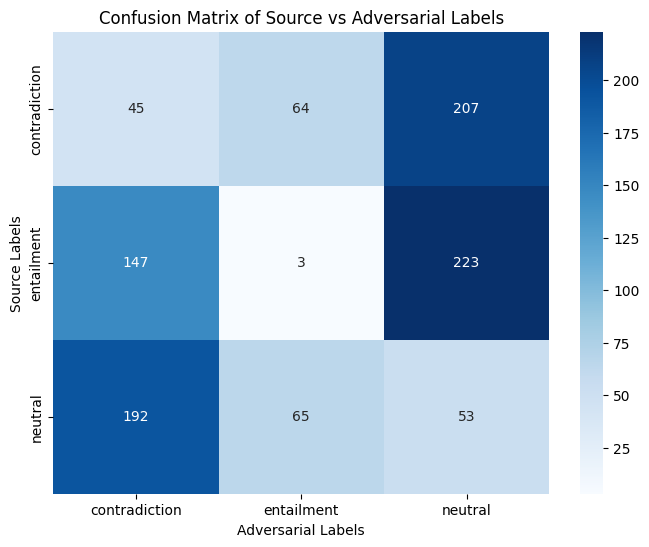

In [19]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Create confusion matrix
conf_matrix = confusion_matrix(labels, df['advLabel'])

# Step 3: Create a DataFrame for better visualization
conf_matrix_df = pd.DataFrame(conf_matrix, index=[mapping[i] for i in range(3)],
                              columns=[mapping[i] for i in range(3)])

# Calculate accuracy
correct = sum([1 for a, p in zip(labels, df['advLabel']) if a == p])  # Count matching labels
total = len(labels)  # Total number of labels
accuracy = correct / total  # Accuracy calculation
print(f"Accuracy: {accuracy * 100:.2f}%")

# Step 4: Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Adversarial Labels")
plt.ylabel("Source Labels")
plt.title("Confusion Matrix of Source vs Adversarial Labels")
plt.show()

